# Velocity-aware manifold fitting demo

This notebook keeps the original experiment flow, but the report metrics now use the known synthetic ground truth manifold. That means `position_rmse` is computed against the true manifold projection, and `velocity_cosine` is compared with the true tangent field.


## Imports and core utilities

Run this cell first. It defines the parameters, neighborhood construction, local PCA projector, and the velocity-aware fitting loop.


In [9]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Literal, Tuple

import numpy as np
import pandas as pd
from numpy.linalg import norm
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from IPython.display import display

import scvelo as scv
import scanpy as sc

Array = np.ndarray


@dataclass
class VMFParams:
    k: int = 25
    d: int = 1
    n_iter: int = 1
    theta: float = 0.25
    gamma: float = 8.0
    beta: float = 2.0
    kappa: float = 1.0
    eta_g: float = 0.45
    cv: float = 0.15
    max_step_frac: float = 0.35
    random_state: int = 0


def _row_norm(X: Array, eps: float = 1e-12) -> Array:
    return np.sqrt(np.sum(X * X, axis=1, keepdims=True)) + eps


def _cosine_rows(a: Array, b: Array, eps: float = 1e-12) -> Array:
    return np.sum(a * b, axis=1) / ((_row_norm(a, eps)[:, 0]) * (_row_norm(b, eps)[:, 0]) + eps)


def _sigmoid(x: Array) -> Array:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -40, 40)))


def build_velocity_aware_knn(X: Array, W: Array, params: VMFParams) -> Array:
    """Approximate velocity-aware KNN reranking."""
    n = X.shape[0]
    cand_k = min(n - 1, max(params.k * 4, params.k + 5))
    nn = NearestNeighbors(n_neighbors=cand_k + 1).fit(X)
    _, cand = nn.kneighbors(X)
    cand = cand[:, 1:]

    N = np.zeros((n, params.k), dtype=int)
    for i in range(n):
        J = cand[i]
        disp = X[J] - X[i]
        dist = norm(disp, axis=1)
        cos = _cosine_rows(np.repeat(W[i][None, :], len(J), axis=0), disp)
        score = (1 - params.theta) * dist + params.theta * (1 - _sigmoid(params.gamma * cos))
        N[i] = J[np.argsort(score)[: params.k]]
    return N


def local_pca_projector(Z: Array, N: Array, weights: Array, d: int) -> Tuple[Array, Array]:
    """Returns tangent bases U_i and projectors P_i = U_i U_i^T."""
    n, D = Z.shape
    U_all = np.zeros((n, D, d))
    P_all = np.zeros((n, D, D))
    for i in range(n):
        J = N[i]
        C = Z[J] - Z[i]
        w = weights[i][:, None]
        M = (C * w).T @ C
        vals, vecs = np.linalg.eigh(M)
        U = vecs[:, np.argsort(vals)[::-1][:d]]
        U_all[i] = U
        P_all[i] = U @ U.T
    return U_all, P_all


def compute_weights(Z: Array, W: Array, N: Array, params: VMFParams) -> Tuple[Array, Array]:
    """Kernel weights with an optional directional factor."""
    n = Z.shape[0]
    K = N.shape[1]
    weights = np.zeros((n, K))
    h = np.zeros(n)
    for i in range(n):
        J = N[i]
        disp = Z[J] - Z[i]
        dist = norm(disp, axis=1)
        h_i = np.max(dist) + 1e-12
        h[i] = h_i
        radial = np.maximum(1 - (dist / h_i) ** 2, 0.0) ** params.beta
        cos_abs = np.abs(_cosine_rows(np.repeat(W[i][None, :], K, axis=0), disp))
        directional = np.exp(params.kappa * cos_abs)
        w = radial * directional + 1e-12
        weights[i] = w / np.sum(w)
    return weights, h


def project_velocity(W: Array, P: Array) -> Array:
    return np.einsum("nij,nj->ni", P, W)


def fit_velocity_mf(
    X: Array,
    W: Array,
    params: VMFParams,
    mode: Literal["original", "normal_only", "geometric_only", "bidirectional_velocity"] = "original",
    freeze_graph: bool = True,
) -> Dict[str, Array]:
    """Fit the velocity-aware manifold in various modes."""
    Z = X.copy()
    Wcur = W.copy()

    N = build_velocity_aware_knn(Z, Wcur, params)

    for t in range(params.n_iter):
        if (not freeze_graph) and t > 0:
            N = build_velocity_aware_knn(Z, Wcur, params)

        weights, h = compute_weights(Z, Wcur, N, params)
        U, P = local_pca_projector(Z, N, weights, params.d)
        Vproj = project_velocity(Wcur, P)

        Z_new = Z.copy()
        for i in range(Z.shape[0]):
            J = N[i]
            m_i = np.sum(weights[i][:, None] * Z[J], axis=0)
            g_i = m_i - Z[i]

            step_cap = params.max_step_frac * h[i]
            if mode == "original":
                vdir = Vproj[i] / (norm(Vproj[i]) + 1e-12)
                step = params.eta_g * g_i + params.cv * h[i] * vdir
            elif mode == "normal_only":
                normal_g = g_i - P[i] @ g_i
                step = params.eta_g * normal_g
            elif mode == "geometric_only":
                step = params.eta_g * g_i
            elif mode == "bidirectional_velocity":
                cosine = _cosine_rows(Vproj[i][None, :], g_i[None, :])[0]
                vdir = Vproj[i] / (norm(Vproj[i]) + 1e-12)
                if cosine <= 0:
                    vdir = -vdir
                step = params.eta_g * g_i + params.cv * h[i] * vdir
            else:
                raise ValueError("Invalid mode")

            s_norm = norm(step)
            if s_norm > step_cap:
                step = step * (step_cap / (s_norm + 1e-12))
            Z_new[i] = Z[i] + step

        Z = Z_new
        Wcur = Vproj

    weights, h = compute_weights(Z, Wcur, N, params)
    U, P = local_pca_projector(Z, N, weights, params.d)
    Vproj = project_velocity(W, P)
    return {"Z": Z, "V": Vproj, "N": N, "U": U, "P": P}


## Synthetic data and ground-truth metrics


In [10]:
def make_circle(n: int = 600, sigma_x: float = 0.08, sigma_v: float = 0.25, seed: int = 0):
    rng = np.random.default_rng(seed)
    t = np.sort(rng.uniform(0, 2 * np.pi, size=n))
    X0 = np.c_[np.cos(t), np.sin(t), np.zeros(n)]
    V0 = np.c_[-np.sin(t), np.cos(t), np.zeros(n)]
    X = X0 + rng.normal(scale=sigma_x, size=X0.shape)
    W = V0 + rng.normal(scale=sigma_v, size=V0.shape)
    return X, W, X0, V0, t, None


def make_yshape(n_per_branch: int = 220, sigma_x: float = 0.06, sigma_v: float = 0.22, seed: int = 1):
    rng = np.random.default_rng(seed)
    angles = np.array([np.pi / 2, 7 * np.pi / 6, 11 * np.pi / 6])
    X0_list, V0_list, branch = [], [], []
    for b, a in enumerate(angles):
        r = np.sort(rng.uniform(0.05, 1.0, size=n_per_branch))
        direction = np.array([np.cos(a), np.sin(a), 0.0])
        X0_list.append(r[:, None] * direction[None, :])
        V0_list.append(np.repeat(direction[None, :], n_per_branch, axis=0))
        branch += [b] * n_per_branch
    X0 = np.vstack(X0_list)
    V0 = np.vstack(V0_list)
    branch = np.array(branch)
    X = X0 + rng.normal(scale=sigma_x, size=X0.shape)
    W = V0 + rng.normal(scale=sigma_v, size=V0.shape)
    return X, W, X0, V0, branch, branch


def make_xshape(n_per_branch: int = 220, sigma_x: float = 0.06, sigma_v: float = 0.22, seed: int = 2):
    rng = np.random.default_rng(seed)
    angles = np.array([np.pi / 4, 3 * np.pi / 4, 5 * np.pi / 4, 7 * np.pi / 4])
    X0_list, V0_list, branch = [], [], []
    for b, a in enumerate(angles):
        r = np.sort(rng.uniform(0.08, 1.0, size=n_per_branch))
        direction = np.array([np.cos(a), np.sin(a), 0.0])
        X0_list.append(r[:, None] * direction[None, :])
        V0_list.append(np.repeat(direction[None, :], n_per_branch, axis=0))
        branch += [b] * n_per_branch
    X0 = np.vstack(X0_list)
    V0 = np.vstack(V0_list)
    branch = np.array(branch)
    X = X0 + rng.normal(scale=sigma_x, size=X0.shape)
    W = V0 + rng.normal(scale=sigma_v, size=V0.shape)
    return X, W, X0, V0, branch, branch


def make_swiss_roll(n: int = 900, sigma_x: float = 0.05, sigma_v: float = 0.18, seed: int = 3):
    rng = np.random.default_rng(seed)
    t = np.sort(rng.uniform(1.5 * np.pi, 4.5 * np.pi, size=n))
    h = rng.uniform(0.0, 8.0, size=n)
    X0 = np.c_[t * np.cos(t), h, t * np.sin(t)]
    dt = np.c_[np.cos(t) - t * np.sin(t), np.zeros(n), np.sin(t) + t * np.cos(t)]
    dt = dt / (norm(dt, axis=1, keepdims=True) + 1e-12)
    V0 = dt
    X = X0 + rng.normal(scale=sigma_x, size=X0.shape)
    W = V0 + rng.normal(scale=sigma_v, size=V0.shape)
    return X, W, X0, V0, t, None


def _project_circle_truth(X: Array):
    xy = X[:, :2]
    r = norm(xy, axis=1, keepdims=True)
    safe_r = np.maximum(r, 1e-12)
    proj_xy = xy / safe_r
    proj_xy[r[:, 0] < 1e-12] = np.array([1.0, 0.0])
    proj = np.c_[proj_xy, np.zeros(X.shape[0])]
    tangent = np.c_[-proj_xy[:, 1], proj_xy[:, 0], np.zeros(X.shape[0])]
    return proj, tangent


def _project_branch_truth(X: Array, angles: Array):
    proj = np.zeros_like(X)
    tangent = np.zeros_like(X)
    best_dist2 = np.full(X.shape[0], np.inf)
    xy = X[:, :2]
    for a in angles:
        direction = np.array([np.cos(a), np.sin(a), 0.0])
        t = np.clip(xy @ direction[:2], 0.0, 1.0)
        cand = t[:, None] * direction[None, :]
        dist2 = np.sum((X - cand) ** 2, axis=1)
        mask = dist2 < best_dist2
        proj[mask] = cand[mask]
        tangent[mask] = direction
        best_dist2[mask] = dist2[mask]
    return proj, tangent


def _project_yshape_truth(X: Array):
    return _project_branch_truth(X, np.array([np.pi / 2, 7 * np.pi / 6, 11 * np.pi / 6]))


def _project_xshape_truth(X: Array):
    return _project_branch_truth(X, np.array([np.pi / 4, 3 * np.pi / 4, 5 * np.pi / 4, 7 * np.pi / 4]))


def _project_swiss_roll_truth(X: Array):
    t_grid = np.linspace(1.5 * np.pi, 4.5 * np.pi, 8192)
    curve = np.c_[t_grid * np.cos(t_grid), t_grid * np.sin(t_grid)]
    tangent = np.c_[np.cos(t_grid) - t_grid * np.sin(t_grid), np.sin(t_grid) + t_grid * np.cos(t_grid)]
    tangent = tangent / (norm(tangent, axis=1, keepdims=True) + 1e-12)

    proj = np.zeros_like(X)
    true_tangent = np.zeros_like(X)
    xz = X[:, [0, 2]]
    best_dist2 = np.full(X.shape[0], np.inf)
    for start in range(0, len(t_grid), 512):
        stop = min(start + 512, len(t_grid))
        cand = curve[start:stop]
        diff = xz[:, None, :] - cand[None, :, :]
        dist2 = np.sum(diff * diff, axis=2)
        local_idx = np.argmin(dist2, axis=1)
        local_best = dist2[np.arange(X.shape[0]), local_idx]
        mask = local_best < best_dist2
        best_dist2[mask] = local_best[mask]
        proj[mask, 0] = cand[local_idx[mask], 0]
        proj[mask, 1] = X[mask, 1]
        proj[mask, 2] = cand[local_idx[mask], 1]
        true_tangent[mask, 0] = tangent[start + local_idx[mask], 0]
        true_tangent[mask, 1] = 0.0
        true_tangent[mask, 2] = tangent[start + local_idx[mask], 1]
    return proj, true_tangent


def true_manifold_projection(dataset_name: str, X: Array):
    if dataset_name == "circle":
        return _project_circle_truth(X)
    if dataset_name == "yshape":
        return _project_yshape_truth(X)
    if dataset_name == "xshape":
        return _project_xshape_truth(X)
    if dataset_name == "swiss_roll":
        return _project_swiss_roll_truth(X)
    raise ValueError(dataset_name)


def velocity_cosine(Vhat: Array, Vtrue: Array) -> float:
    c = _cosine_rows(Vhat, Vtrue)
    return float(np.nanmean(c))


def knn_preservation(X: Array, Z: Array, k: int = 20) -> float:
    I1 = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(return_distance=False)[:, 1:]
    I2 = NearestNeighbors(n_neighbors=k + 1).fit(Z).kneighbors(return_distance=False)[:, 1:]
    return float(np.mean([len(set(I1[i]).intersection(I2[i])) / k for i in range(X.shape[0])]))


def branch_mixing_score(Z: Array, labels: Array, k: int = 20) -> float:
    I = NearestNeighbors(n_neighbors=k + 1).fit(Z).kneighbors(return_distance=False)[:, 1:]
    mix = np.mean([np.mean(labels[I[i]] != labels[i]) for i in range(Z.shape[0])])
    return float(mix)


def evaluate(name: str, dataset_name: str, X: Array, Z: Array, V: Array, labels=None) -> Dict[str, float]:
    Z_proj, V_true = true_manifold_projection(dataset_name, Z)
    point_err = norm(Z - Z_proj, axis=1)
    cos = _cosine_rows(V, V_true)
    row = {
        "method": name,
        "position_rmse": float(np.sqrt(np.mean(point_err ** 2))),
        "point_to_manifold_error_mean": float(np.mean(point_err)),
        "velocity_cosine": float(np.nanmean(cos)),
        "velocity_tangent_distance_mean": float(np.mean(np.sqrt(np.maximum(0.0, 1.0 - cos ** 2)))),
        "knn_preservation": knn_preservation(X, Z, k=20),
    }
    if labels is not None:
        row["branch_mixing"] = branch_mixing_score(Z, labels, k=20)
    return row


## Plotting and experiment helpers

The next cell reproduces the script output and also keeps the figures available inline. It includes a dedicated 3D plot for the swiss roll example.


In [11]:
def _set_3d_limits(ax, X: Array):
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    centers = (mins + maxs) / 2
    spans = maxs - mins
    radius = float(np.max(spans) / 2)
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def plot_results(dataset_name: str, X: Array, results: Dict[str, Dict[str, Array]], labels=None):
    ncols = 1 + len(results)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4), constrained_layout=True)
    if ncols == 1:
        axes = [axes]

    color = labels if labels is not None else np.arange(X.shape[0])
    axes[0].scatter(X[:, 0], X[:, 1], c=color, s=8)
    axes[0].set_title(f"{dataset_name}: noisy input")
    axes[0].set_aspect("equal")

    for ax, (name, out) in zip(axes[1:], results.items()):
        Z = out["Z"]
        V = out["V"]
        ax.scatter(Z[:, 0], Z[:, 1], c=color, s=8)
        step = max(1, Z.shape[0] // 80)
        ax.quiver(
            Z[::step, 0], Z[::step, 1],
            V[::step, 0], V[::step, 1],
            angles="xy", scale_units="xy", scale=18, width=0.003,
        )
        ax.set_title(name)
        ax.set_aspect("equal")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    return fig


def plot_results_3d(dataset_name: str, X: Array, results: Dict[str, Dict[str, Array]], labels=None):
    ncols = 1 + len(results)
    fig = plt.figure(figsize=(4 * ncols, 4))
    color = labels if labels is not None else np.arange(X.shape[0])

    ax0 = fig.add_subplot(1, ncols, 1, projection="3d")
    ax0.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, s=7)
    ax0.set_title(f"{dataset_name}: noisy input")
    ax0.view_init(elev=20, azim=-60)
    _set_3d_limits(ax0, X)

    for idx, (name, out) in enumerate(results.items(), start=2):
        Z = out["Z"]
        V = out["V"]
        ax = fig.add_subplot(1, ncols, idx, projection="3d")
        ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=color, s=7)
        step = max(1, Z.shape[0] // 120)
        ax.quiver(
            Z[::step, 0], Z[::step, 1], Z[::step, 2],
            V[::step, 0], V[::step, 1], V[::step, 2],
            length=0.5, normalize=True, color="black", linewidth=0.6,
        )
        ax.set_title(name)
        ax.view_init(elev=20, azim=-60)
        _set_3d_limits(ax, Z)

    return fig


def run_one_experiment(dataset: Literal["circle", "yshape", "xshape", "swiss_roll"], seed: int = 0, outdir: str = "velocity_mf_outputs"):
    Path(outdir).mkdir(parents=True, exist_ok=True)

    if dataset == "circle":
        X, W, X0, V0, plot_labels, mix_labels = make_circle(seed=seed)
        params = VMFParams(k=25, d=1, n_iter=10, eta_g=0.45, cv=0.15, theta=0.25)
        fig_fn = plot_results
    elif dataset == "yshape":
        X, W, X0, V0, plot_labels, mix_labels = make_yshape(seed=seed)
        params = VMFParams(k=25, d=1, n_iter=10, eta_g=0.45, cv=0.15, theta=0.25)
        fig_fn = plot_results
    elif dataset == "xshape":
        X, W, X0, V0, plot_labels, mix_labels = make_xshape(seed=seed)
        params = VMFParams(k=25, d=1, n_iter=10, eta_g=0.45, cv=0.15, theta=0.25)
        fig_fn = plot_results
    elif dataset == "swiss_roll":
        X, W, X0, V0, plot_labels, mix_labels = make_swiss_roll(seed=seed)
        params = VMFParams(k=35, d=2, n_iter=12, eta_g=0.35, cv=0.12, theta=0.20, max_step_frac=0.30)
        fig_fn = plot_results_3d
    else:
        raise ValueError(dataset)

    params.random_state = seed

    original = fit_velocity_mf(X, W, params, mode="original")
    normal = fit_velocity_mf(X, W, params, mode="normal_only")
    geometric_only = fit_velocity_mf(X, W, params, mode="geometric_only")
    bidirectional = fit_velocity_mf(X, W, params, mode="bidirectional_velocity")

    rows = [
        evaluate("raw", dataset, X, X, W, mix_labels),
        evaluate("original_full_meanshift", dataset, X, original["Z"], original["V"], mix_labels),
        evaluate("normal_only", dataset, X, normal["Z"], normal["V"], mix_labels),
        evaluate("geometric_only", dataset, X, geometric_only["Z"], geometric_only["V"], mix_labels),
        evaluate("bidirectional_velocity", dataset, X, bidirectional["Z"], bidirectional["V"], mix_labels),
    ]
    df = pd.DataFrame(rows)

    fig = fig_fn(dataset, X, {"original full update": original, "normal-only update": normal, "geometric only": geometric_only, "bidirectional velocity": bidirectional}, labels=plot_labels)
    fig.savefig(Path(outdir) / f"{dataset}_comparison.png", dpi=180)

    df.to_csv(Path(outdir) / f"{dataset}_metrics.csv", index=False)
    return df, original, normal, (X, W, X0, V0, plot_labels, mix_labels), fig


## Metrics (true manifold)


,method,position_rmse,point_to_manifold_error_mean,velocity_cosine,velocity_tangent_distance_mean,knn_preservation
0,raw,0.112106,0.100257,0.938627,0.304506,1.000000
1,original_full_meanshift,0.034141,0.030481,0.988979,0.089160,0.649250
2,normal_only,0.110376,0.099158,0.762937,0.572103,0.821167
3,geometric_only,0.029100,0.025246,0.995220,0.091926,0.652417
4,bidirectional_velocity,0.034141,0.030481,0.988979,0.089160,0.649250


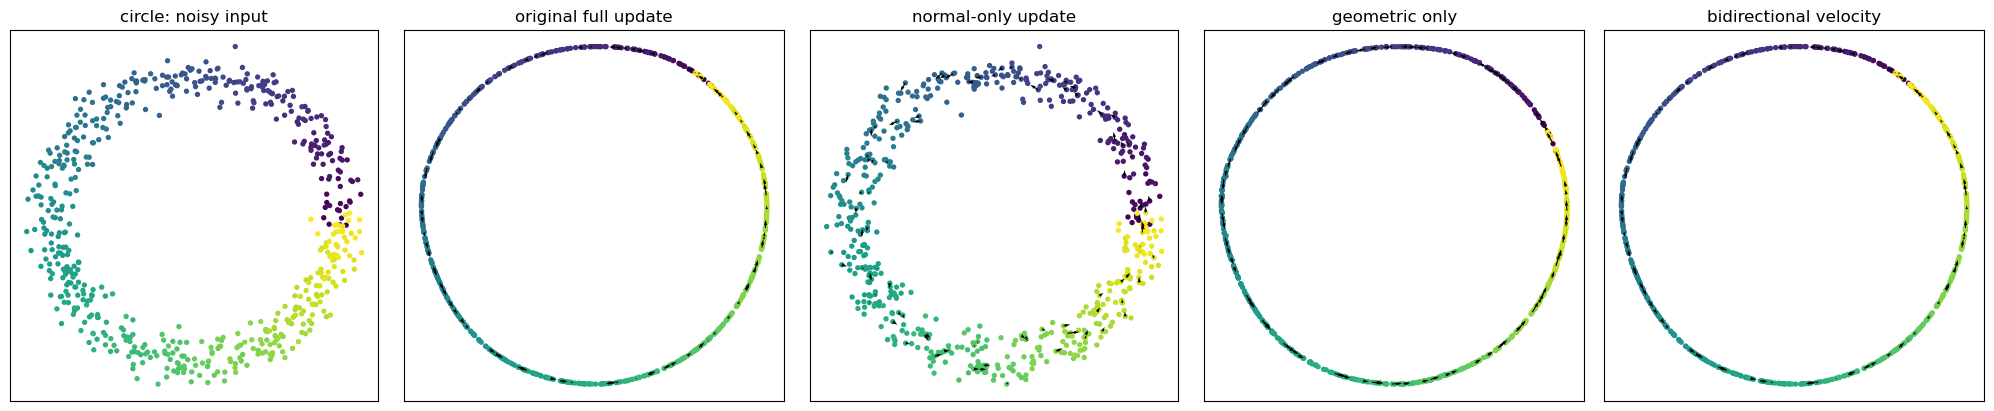

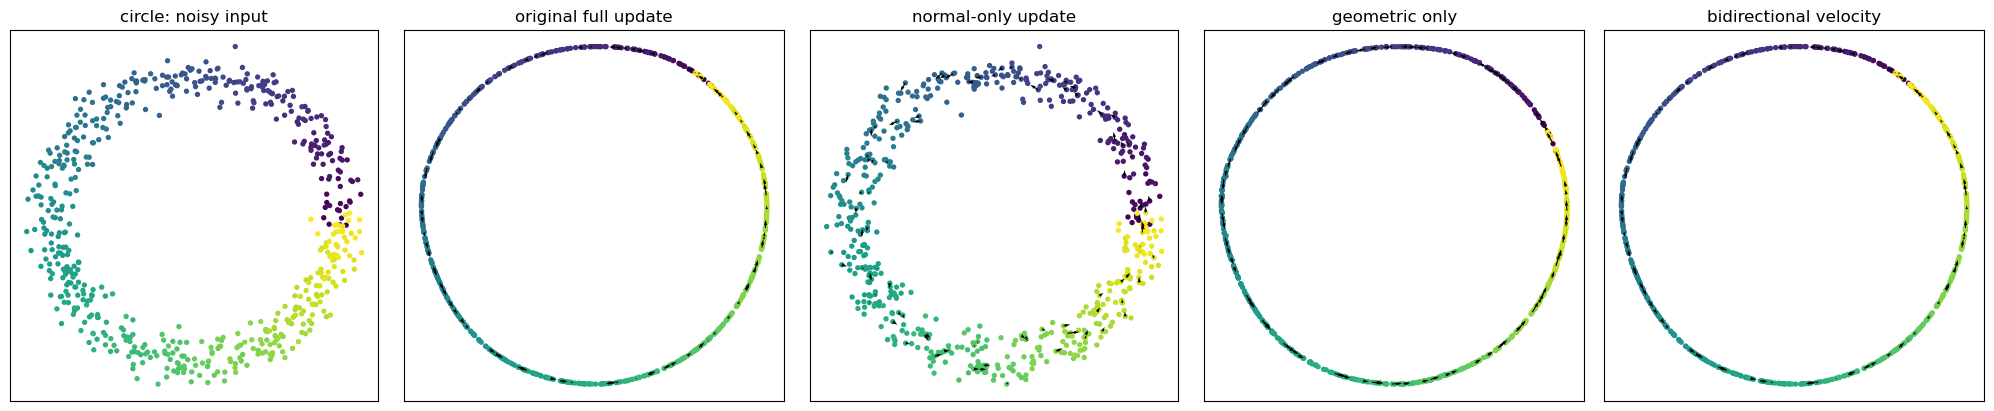

In [12]:
dataset = "circle"
seed = 0

df, original, normal, data, fig = run_one_experiment(dataset, seed=seed)
X, W, X0, V0, plot_labels, mix_labels = data

display(df)
display(fig)


## Y shape comparison


,method,position_rmse,point_to_manifold_error_mean,velocity_cosine,velocity_tangent_distance_mean,knn_preservation,branch_mixing
0,raw,0.085075,0.075384,0.926314,0.276236,1.000000,0.033485
1,original_full_meanshift,0.078208,0.053054,0.589146,0.536912,0.431515,0.000000
2,normal_only,0.089293,0.080730,0.684522,0.632018,0.776061,0.035227
3,geometric_only,0.010092,0.008388,0.833734,0.253045,0.483561,0.002045
4,bidirectional_velocity,0.011310,0.009702,0.836563,0.277066,0.463258,0.001970


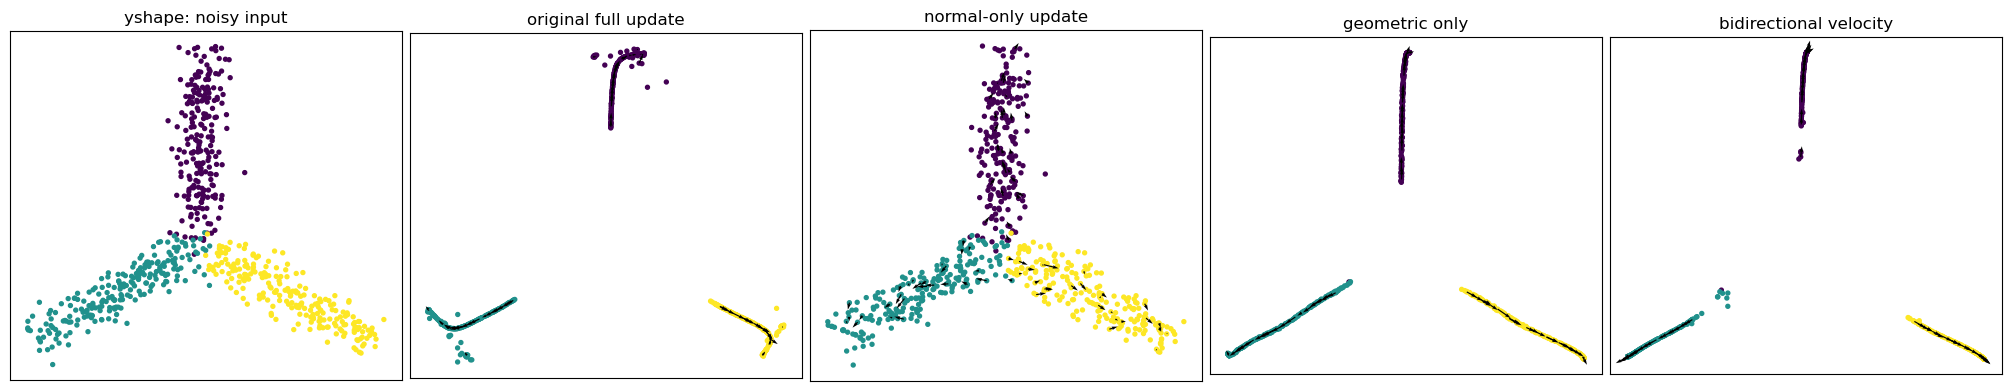

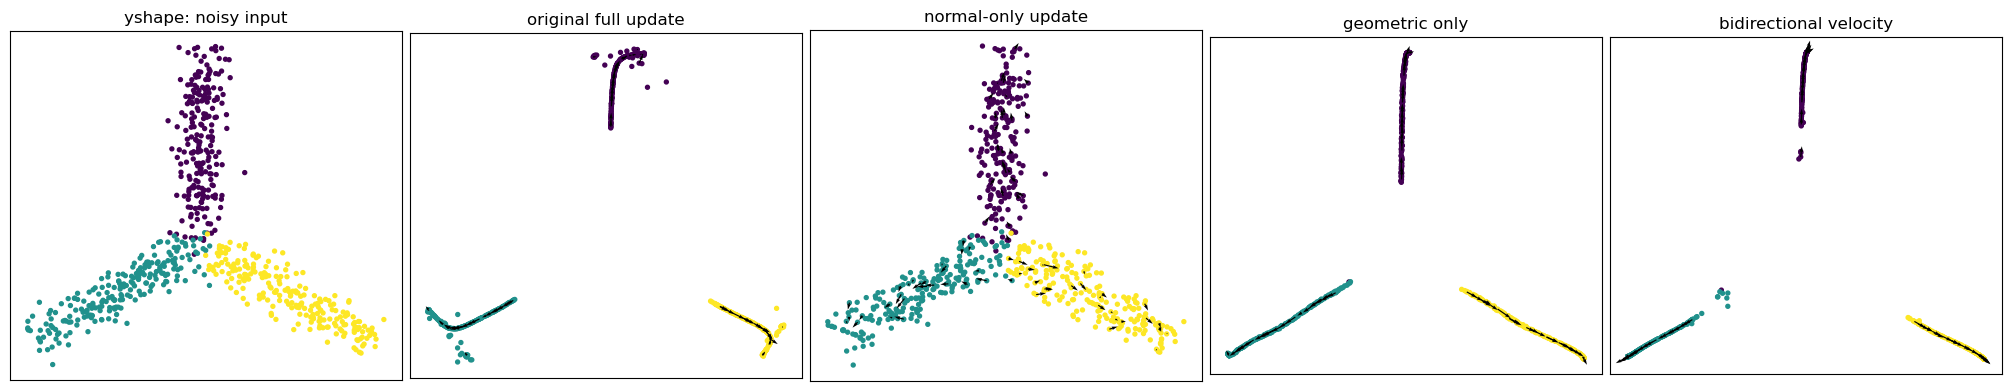

In [13]:
dataset = "yshape"
seed = 1

df, original, normal, data, fig = run_one_experiment(dataset, seed=seed)
X, W, X0, V0, plot_labels, mix_labels = data

display(df)
display(fig)


## X shape comparison


,method,position_rmse,point_to_manifold_error_mean,velocity_cosine,velocity_tangent_distance_mean,knn_preservation,branch_mixing
0,raw,0.085505,0.075570,0.940152,0.273586,1.000000,0.031193
1,original_full_meanshift,0.081331,0.054816,0.606439,0.527015,0.423750,0.000000
2,normal_only,0.089922,0.080612,0.678364,0.633140,0.766080,0.033693
3,geometric_only,0.015214,0.013244,0.870606,0.243263,0.489659,0.001136
4,bidirectional_velocity,0.017126,0.015306,0.821338,0.324647,0.461989,0.000000


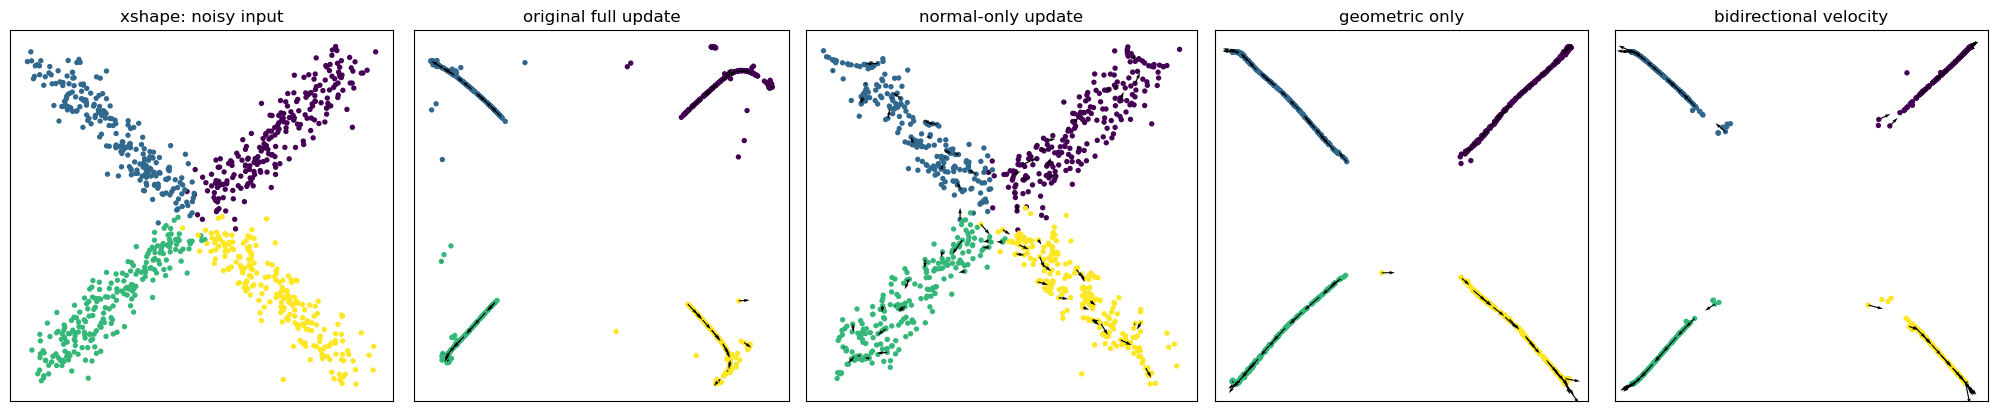

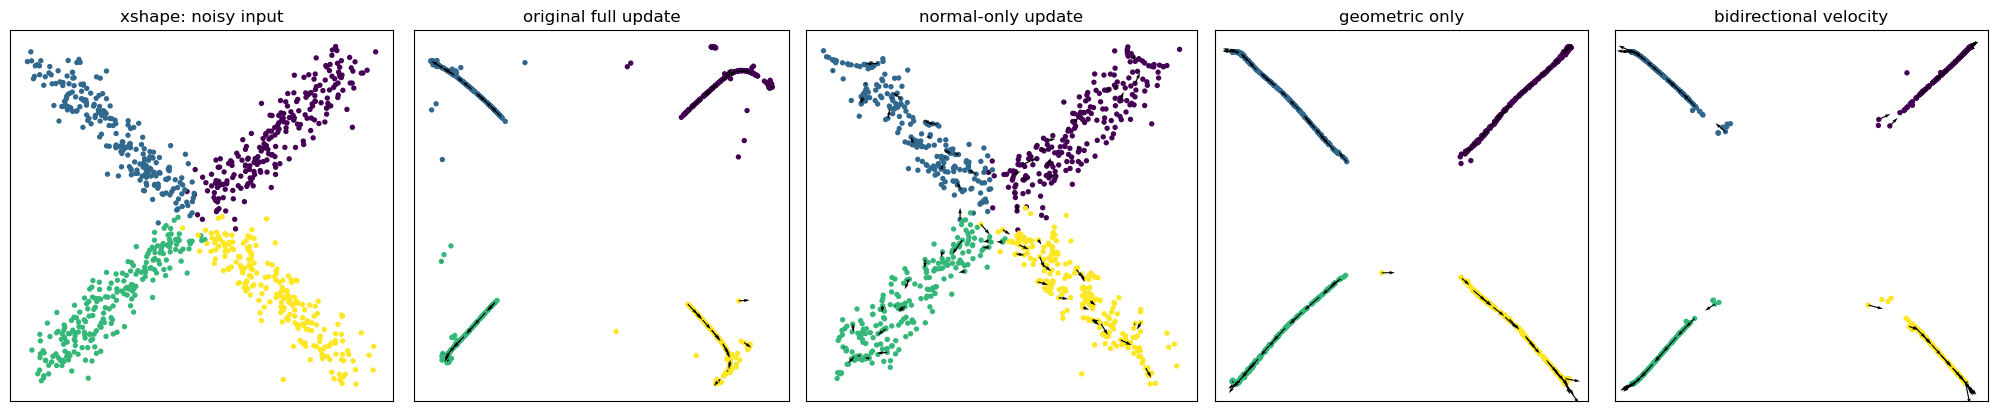

In [14]:
dataset = "xshape"
seed = 2

df, original, normal, data, fig = run_one_experiment(dataset, seed=seed)
X, W, X0, V0, plot_labels, mix_labels = data

display(df)
display(fig)


## 3D Swiss roll comparison


,method,position_rmse,point_to_manifold_error_mean,velocity_cosine,velocity_tangent_distance_mean,knn_preservation
0,raw,0.050374,0.040603,0.966368,0.227335,1.000000
1,original_full_meanshift,0.412164,0.273245,0.943110,0.261974,0.635556
2,normal_only,0.307778,0.297829,0.980128,0.160355,0.984333
3,geometric_only,0.310648,0.297507,0.975031,0.191882,0.709500
4,bidirectional_velocity,0.361987,0.323814,0.958382,0.243315,0.609500


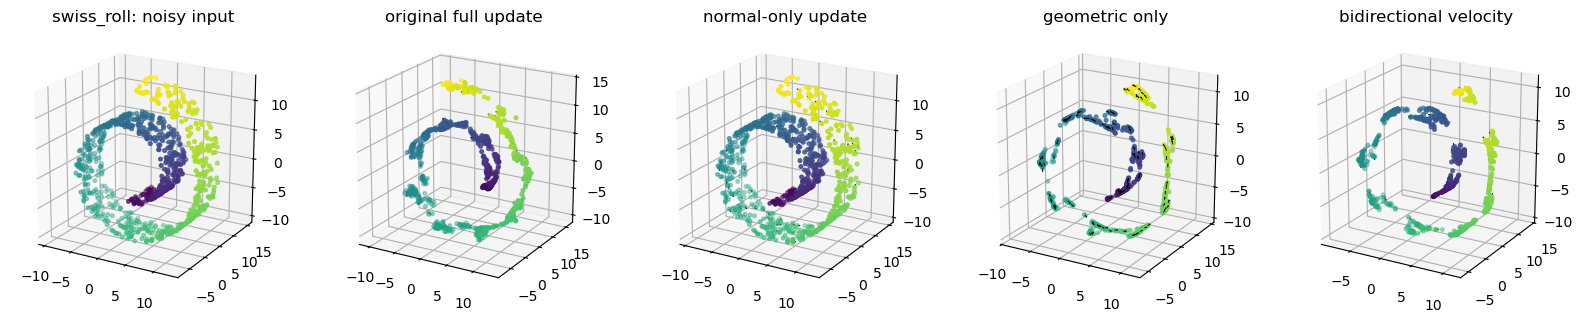

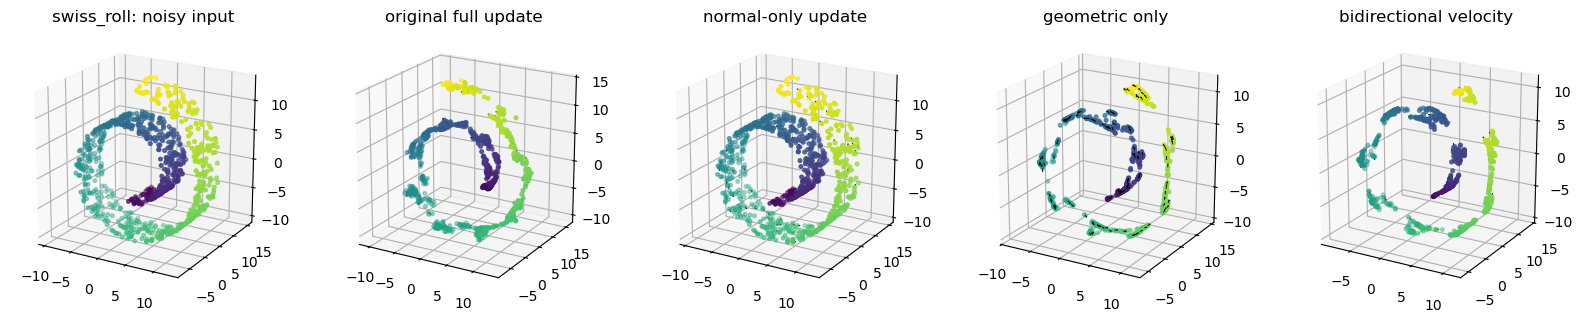

In [15]:
dataset = "swiss_roll"
seed = 3

df, original, normal, data, fig = run_one_experiment(dataset, seed=seed)
X, W, X0, V0, plot_labels, mix_labels = data

display(df)
display(fig)


## Batch run and summary with updated ground-truth metrics


,method,position_rmse,point_to_manifold_error_mean,velocity_cosine,velocity_tangent_distance_mean,knn_preservation,dataset,seed,branch_mixing
0,raw,0.112106,0.100257,0.938627,0.304506,1.000000,circle,0,NaN
1,original_full_meanshift,0.034141,0.030481,0.988979,0.089160,0.649250,circle,0,NaN
2,normal_only,0.110376,0.099158,0.762937,0.572103,0.821167,circle,0,NaN
3,geometric_only,0.029100,0.025246,0.995220,0.091926,0.652417,circle,0,NaN
4,bidirectional_velocity,0.034141,0.030481,0.988979,0.089160,0.649250,circle,0,NaN


position_rmse            \
                                            mean       std   
dataset    method                                            
circle     bidirectional_velocity       0.031245  0.002286   
           geometric_only               0.025262  0.002416   
           normal_only                  0.110027  0.002748   
           original_full_meanshift      0.031307  0.002208   
           raw                          0.113132  0.001685   
swiss_roll bidirectional_velocity       0.333360  0.023242   
           geometric_only               0.299795  0.015529   
           normal_only                  0.303702  0.005149   
           original_full_meanshift      0.499729  0.197857   
           raw                          0.050396  0.000637   
xshape     bidirectional_velocity       0.016069  0.001841   
           geometric_only               0.014888  0.001246   
           normal_only                  0.089580  0.001099   
           original_full_meanshift      0.083468  0.003189   
           raw                          0.085328  0.000920   
yshape     bidirectional_velocity       0.012950  0.003464   
           geometric_only               0.013019  0.002939   
           normal_only                  0.089331  0.001362   
           original_full_meanshift      0.082114  0.011522   
           raw                          0.085141  0.000889   

                                   point_to_manifold_error_mean            \
                                                           mean       std   
dataset    method                                                           
circle     bidirectional_velocity                      0.029119  0.001956   
           geometric_only                              0.022662  0.001897   
           normal_only                                 0.098377  0.002634   
           original_full_meanshift                     0.029183  0.001874   
           raw                                         0.100516  0.001313   
swiss_roll bidirectional_velocity                      0.299996  0.021645   
           geometric_only                              0.286097  0.015532   
           normal_only                                 0.293702  0.004667   
           original_full_meanshift                     0.291561  0.041886   
           raw                                         0.040334  0.000339   
xshape     bidirectional_velocity                      0.013616  0.002113   
           geometric_only                              0.012733  0.001090   
           normal_only                                 0.080991  0.001408   
           original_full_meanshift                     0.055960  0.001527   
           raw                                         0.075758  0.001039   
yshape     bidirectional_velocity                      0.011186  0.002911   
           geometric_only                              0.011224  0.002532   
           normal_only                                 0.080826  0.000846   
           original_full_meanshift                     0.056369  0.009240   
           raw                                         0.075563  0.000377   

                                   velocity_cosine            \
                                              mean       std   
dataset    method                                              
circle     bidirectional_velocity         0.979834  0.011724   
           geometric_only                 0.994441  0.001924   
           normal_only                    0.762945  0.006817   
           original_full_meanshift        0.981140  0.009477   
           raw                            0.935970  0.001930   
swiss_roll bidirectional_velocity         0.965358  0.004302   
           geometric_only                 0.975587  0.001475   
           normal_only                    0.980949  0.000961   
           original_full_meanshift        0.930048  0.009627   
           raw                            0.967835  0.001079   
xsha

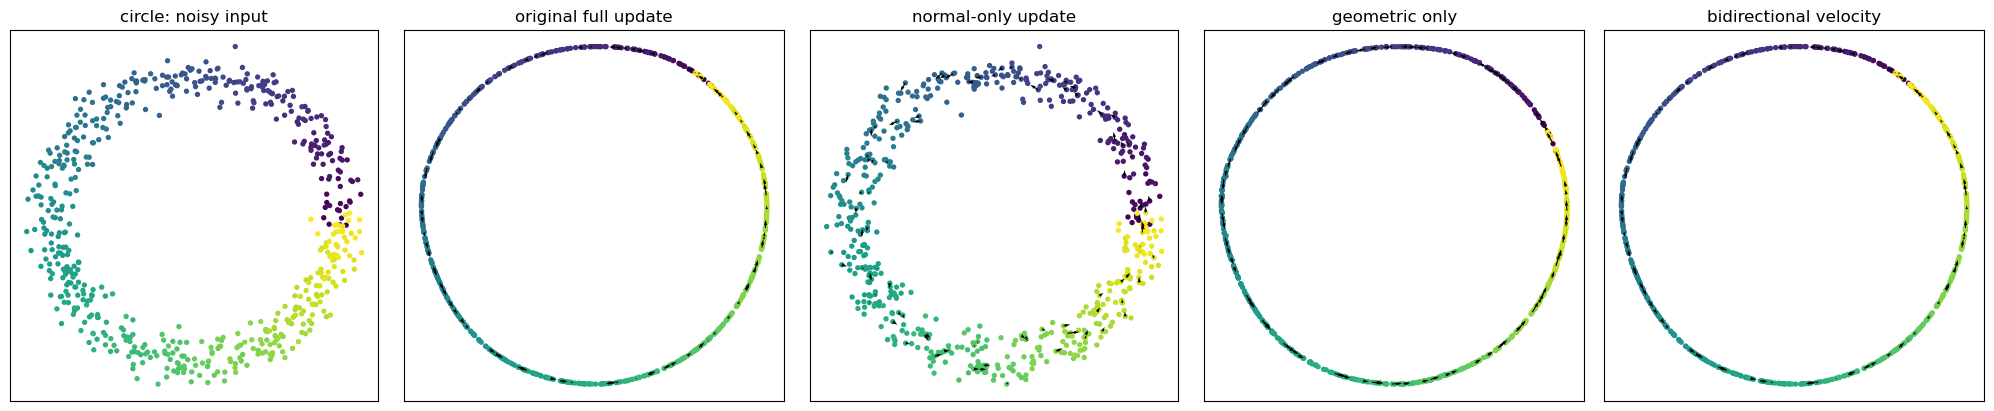

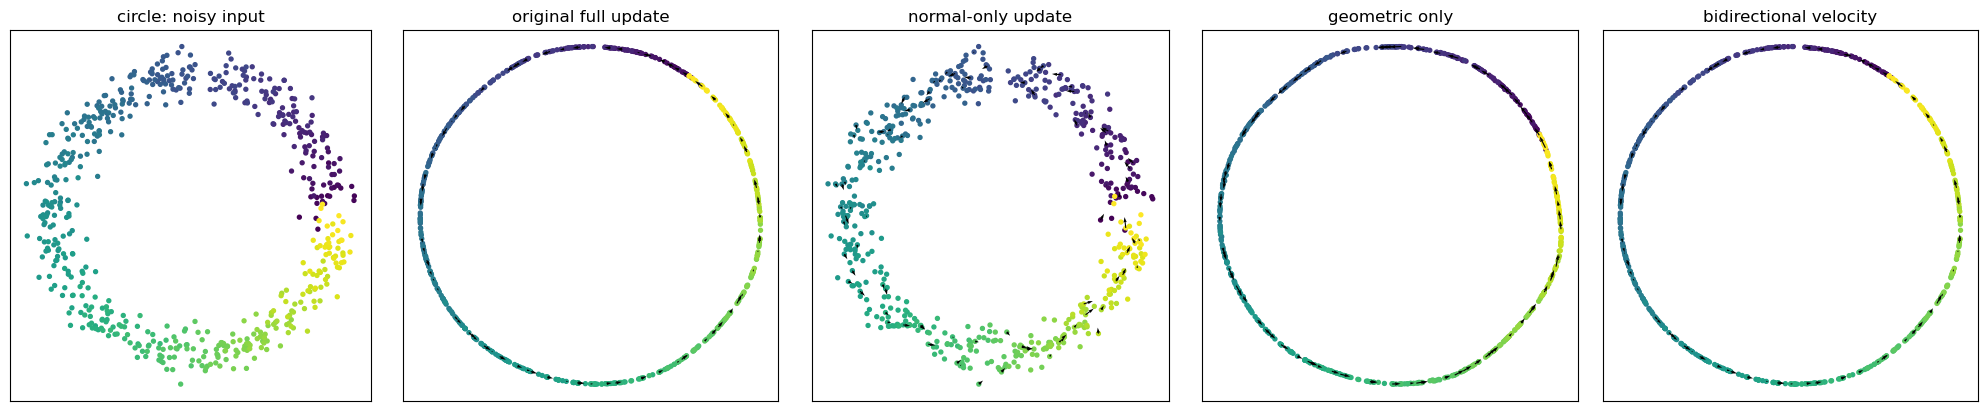

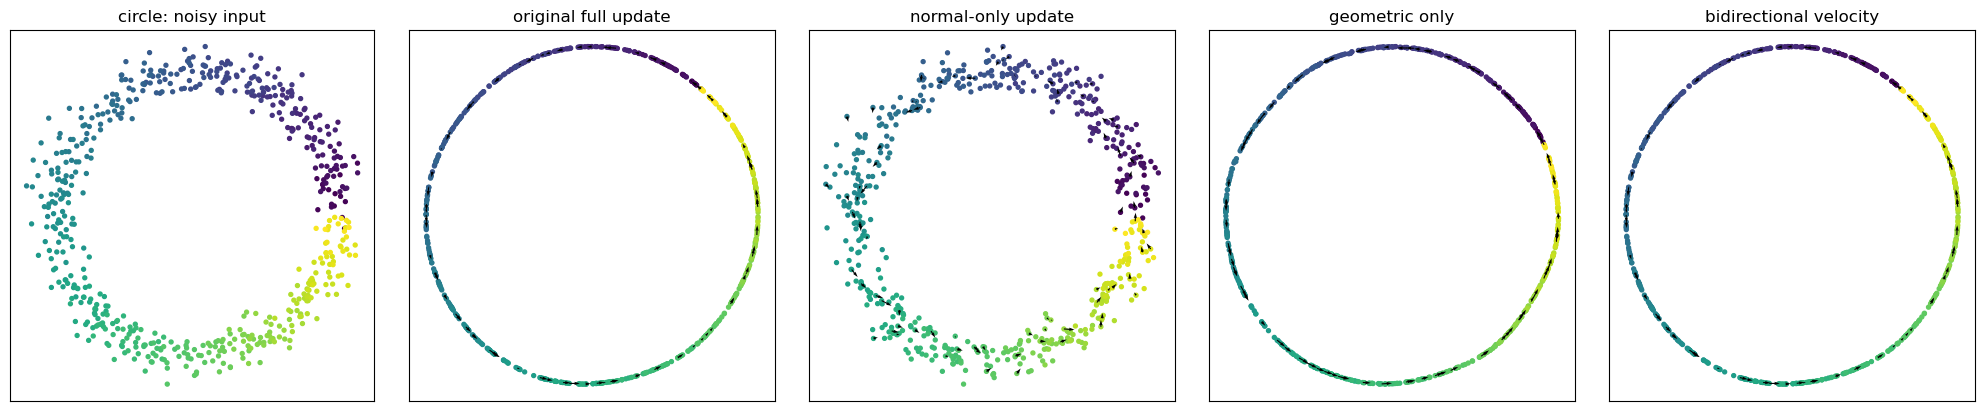

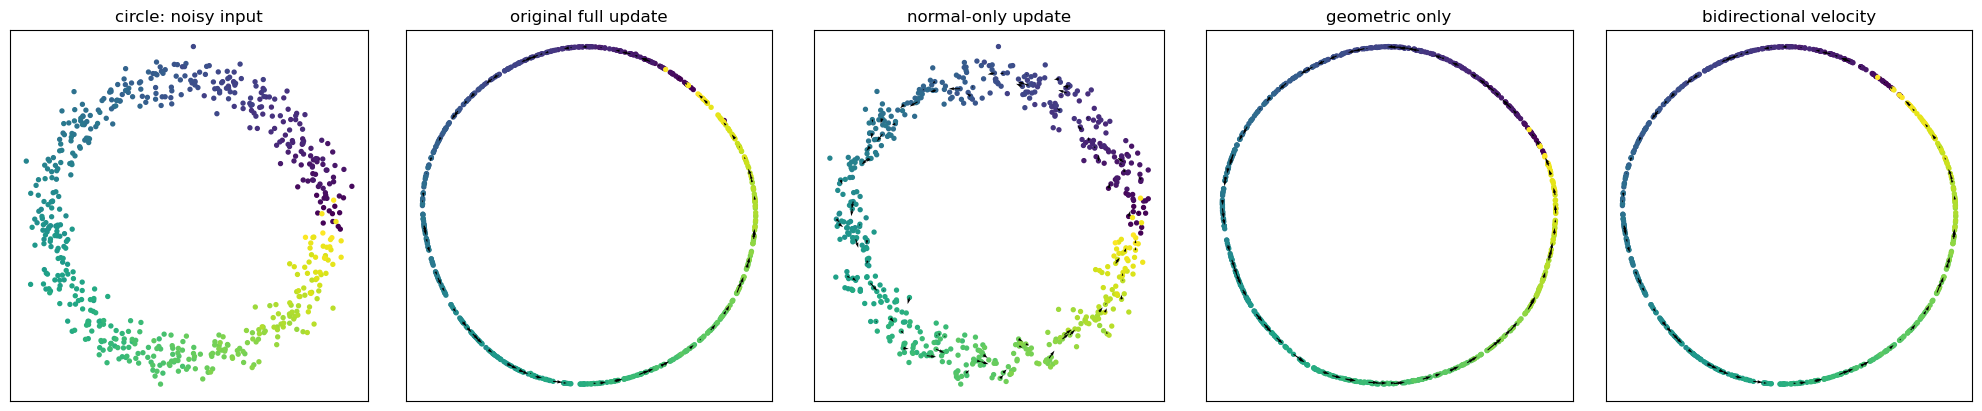

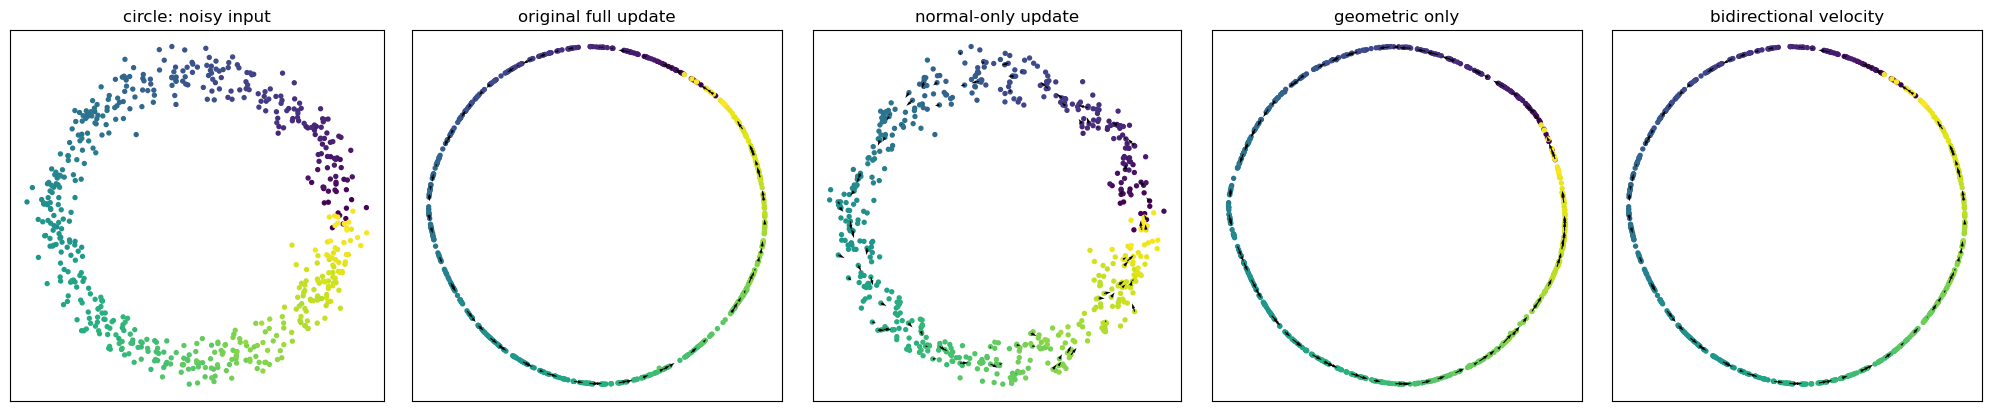

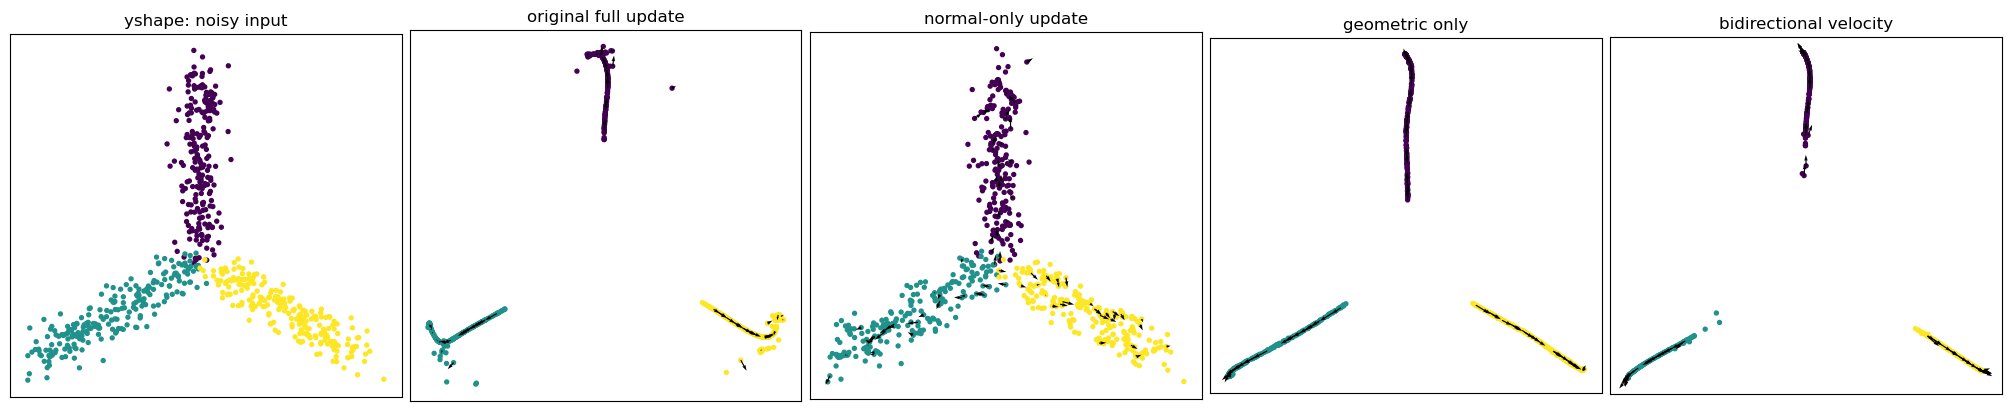

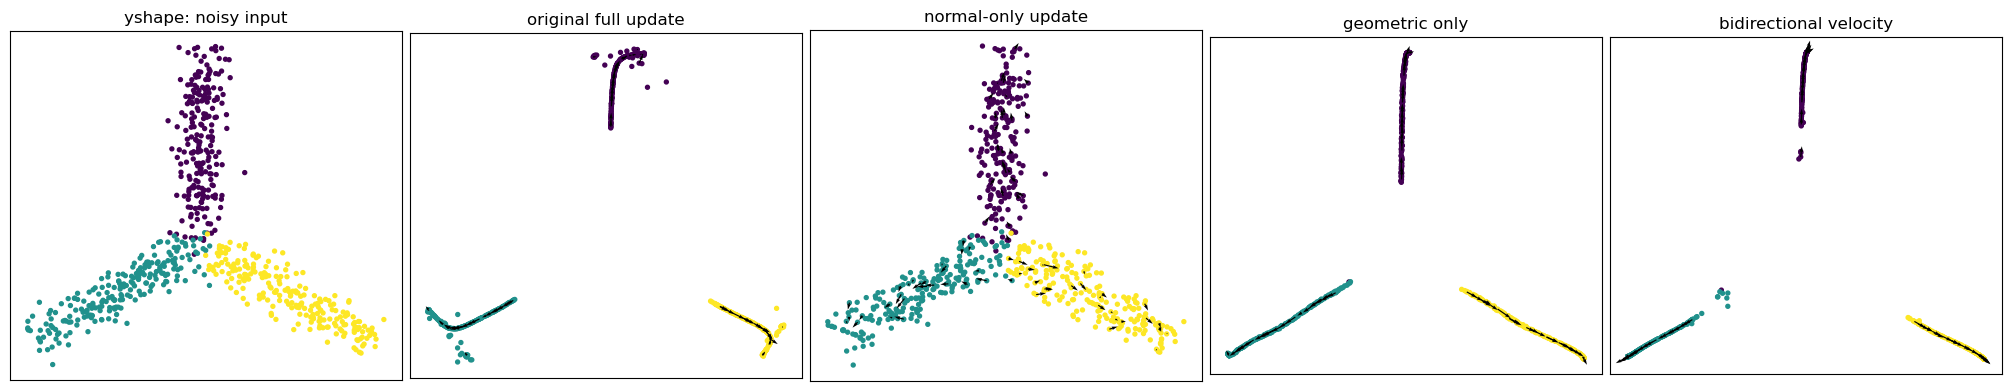

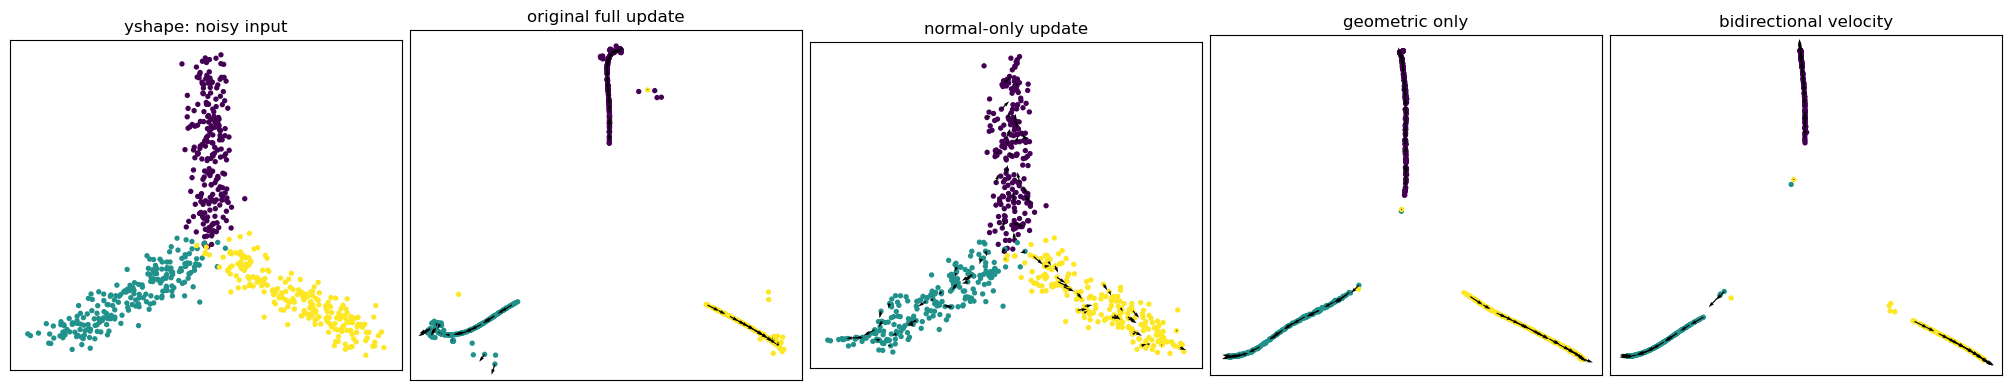

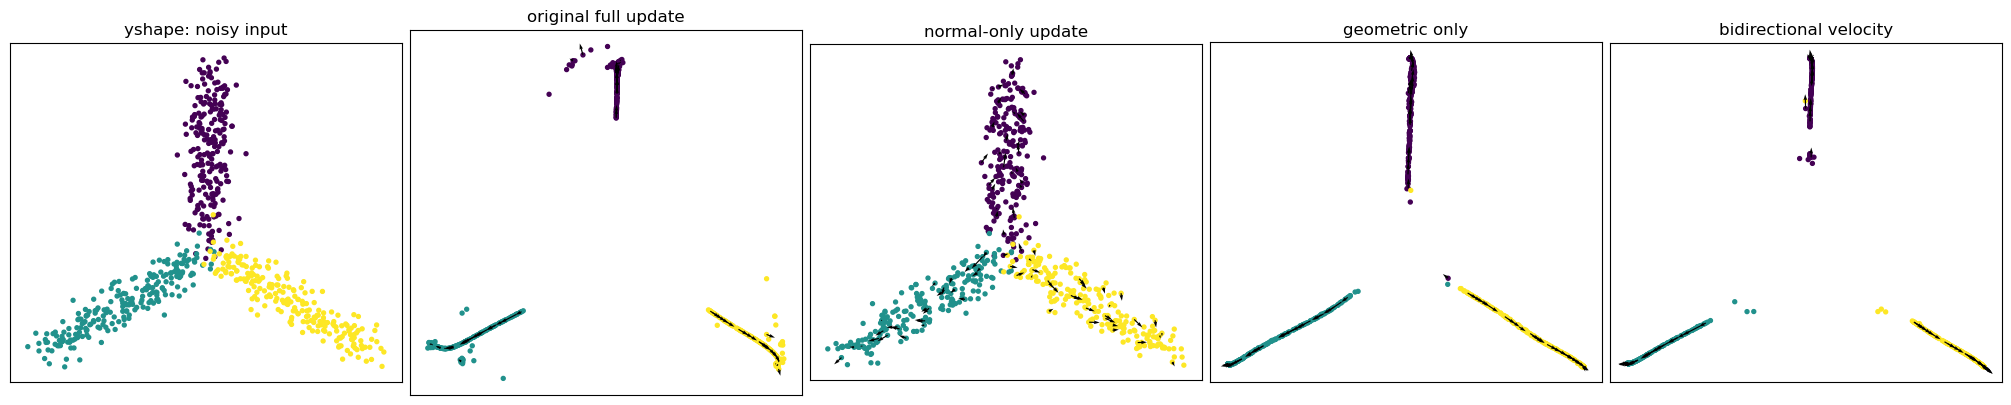

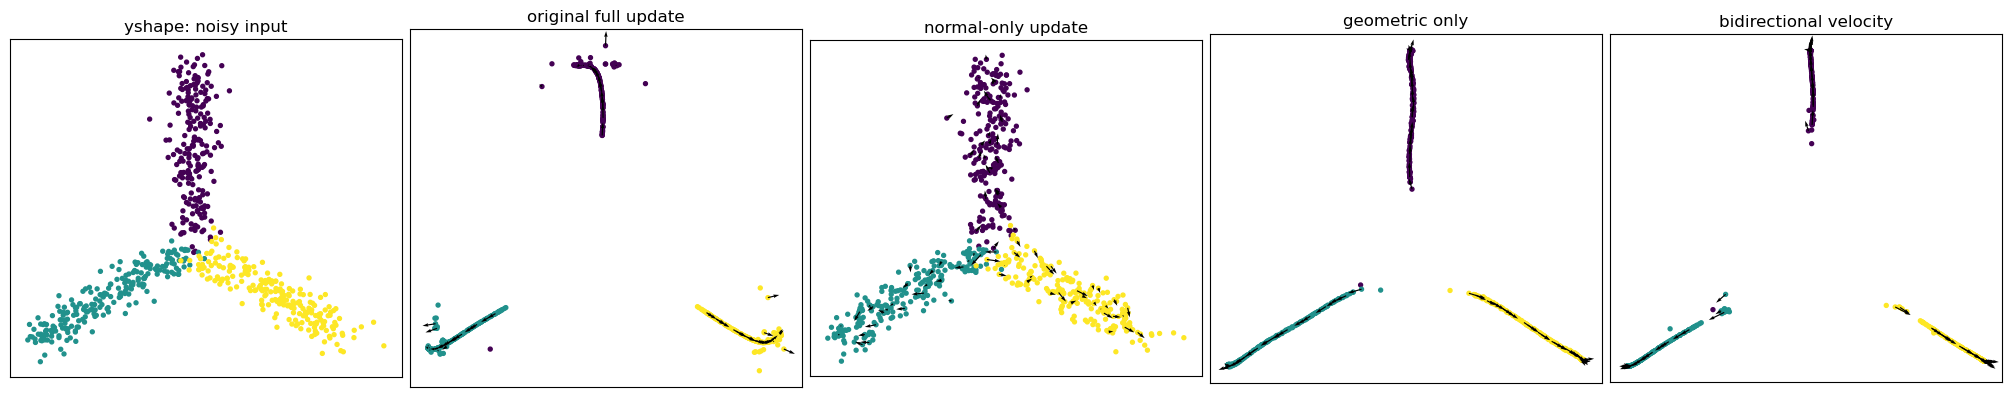

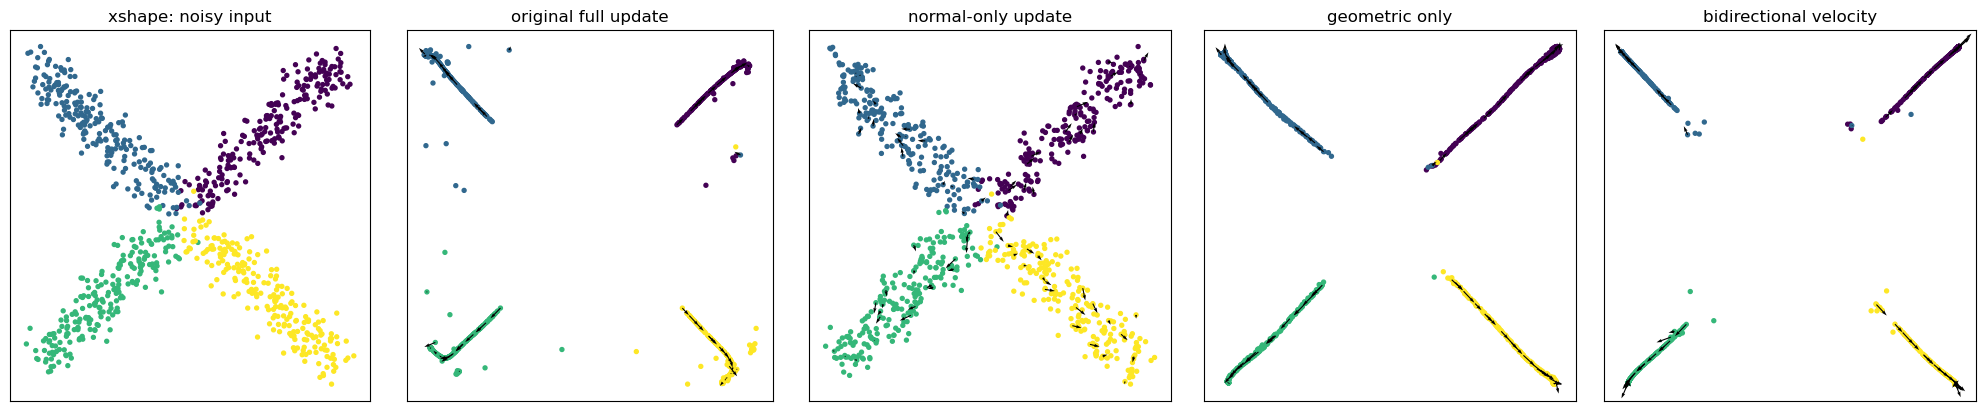

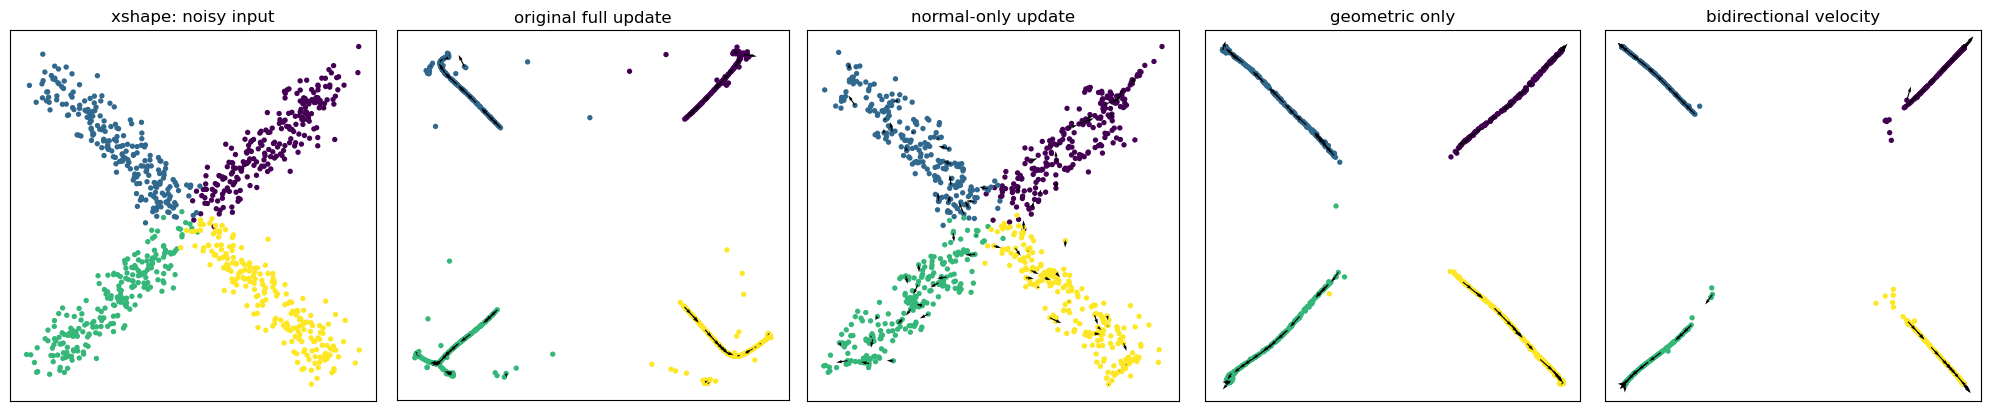

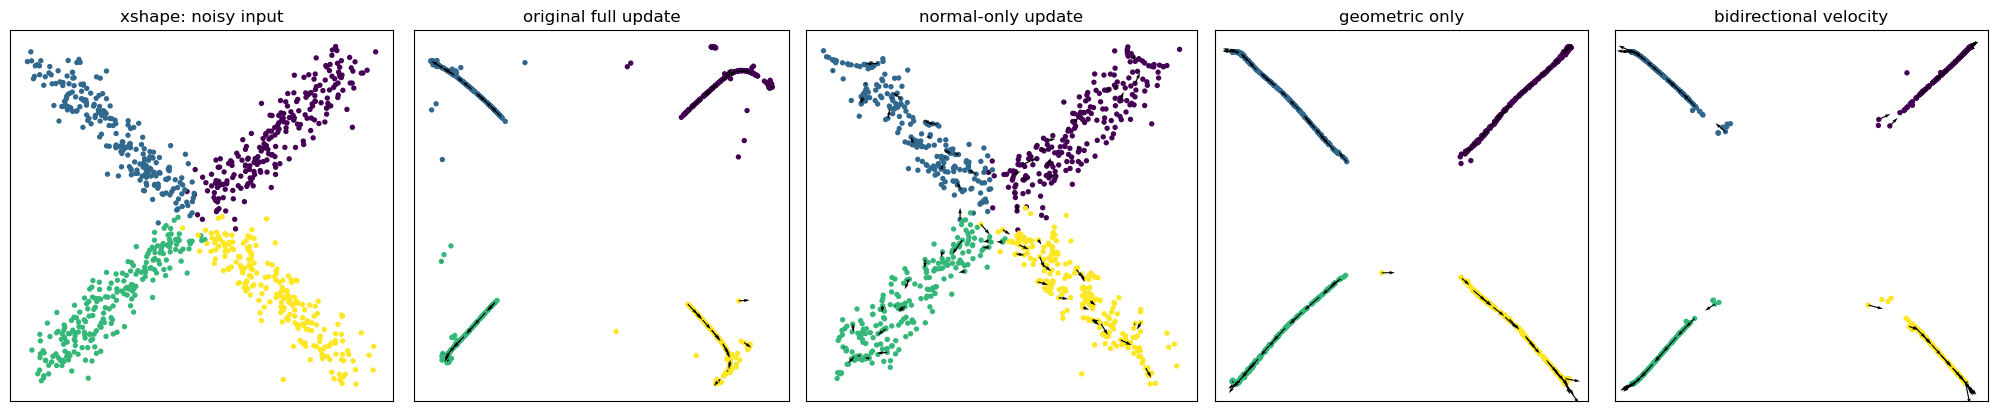

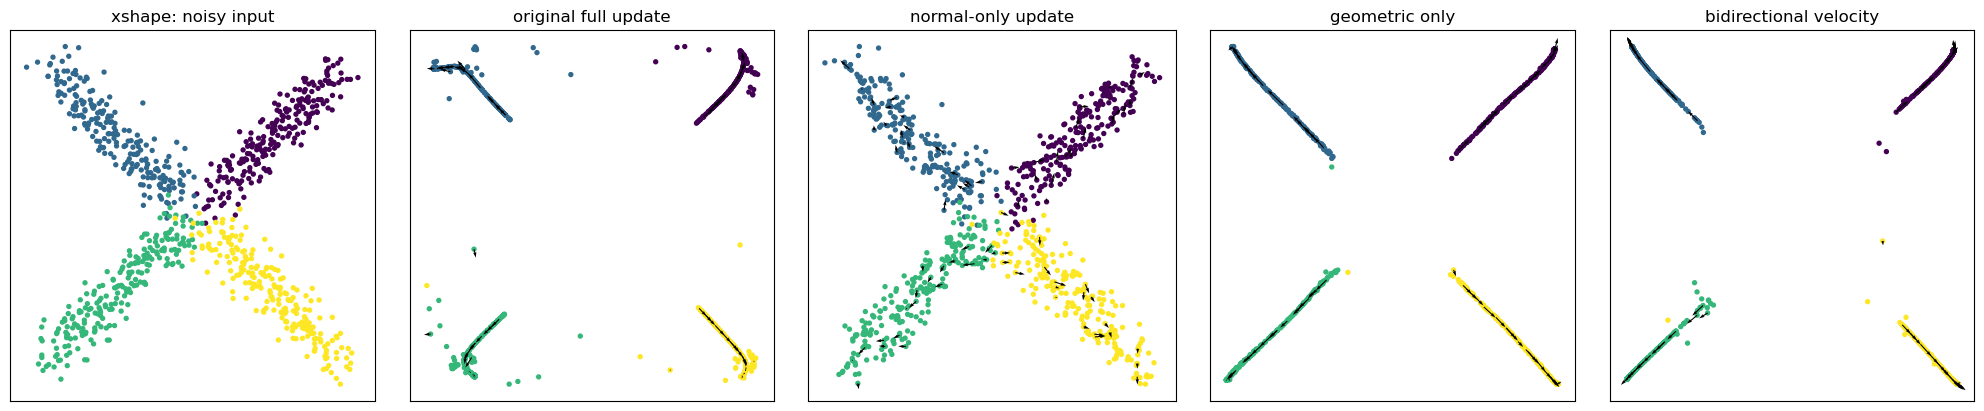

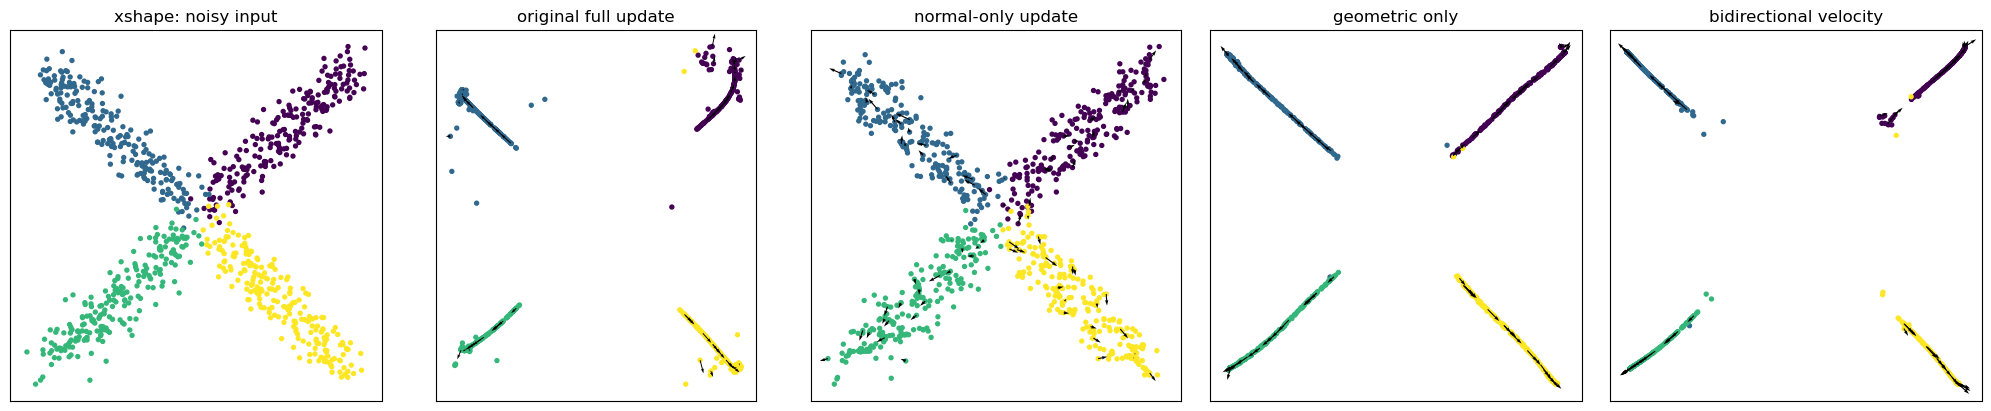

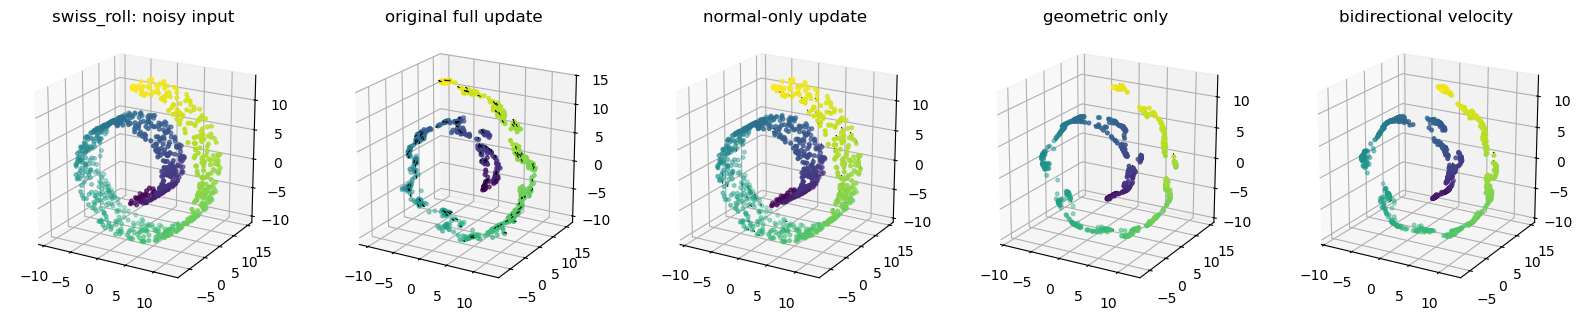

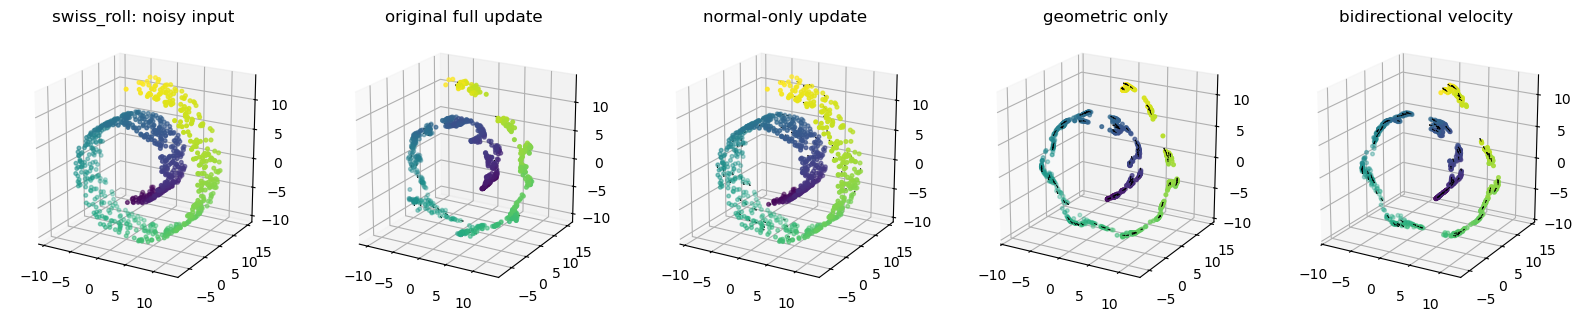

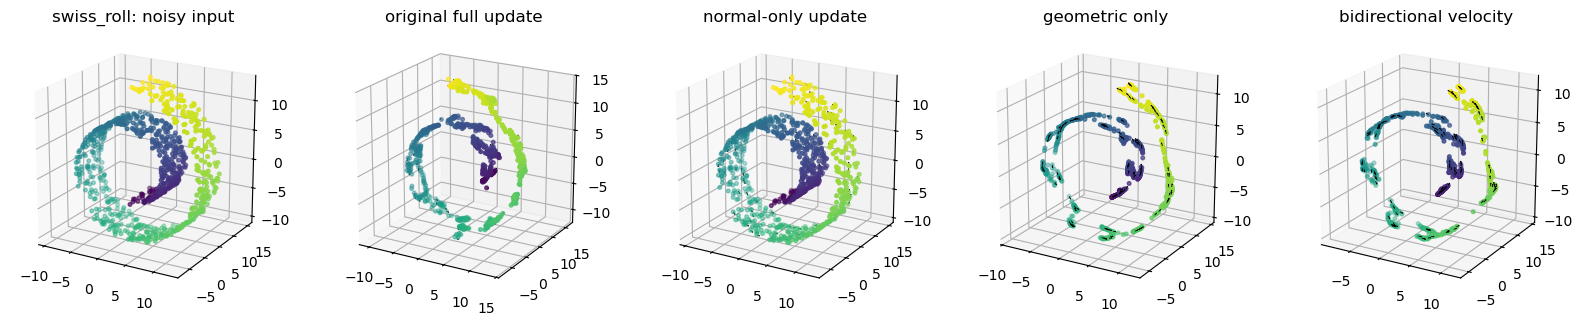

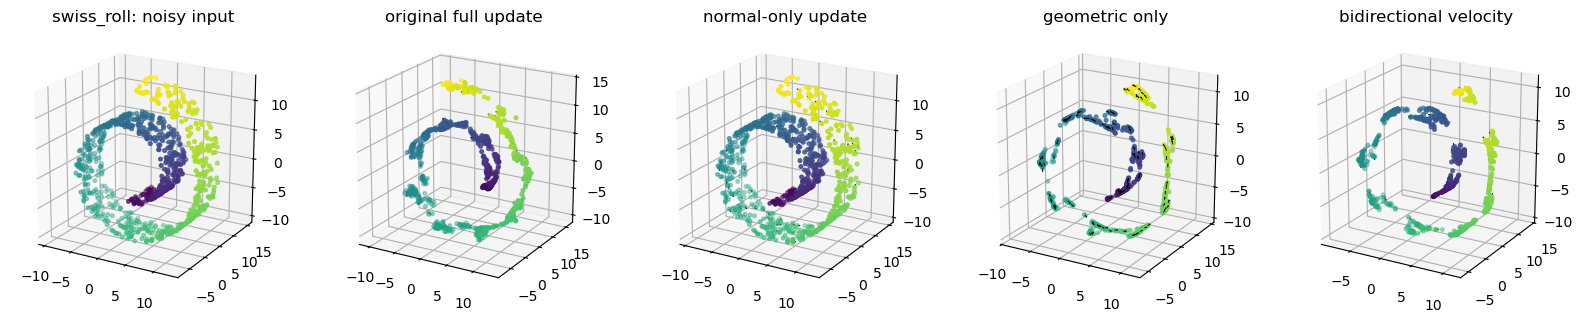

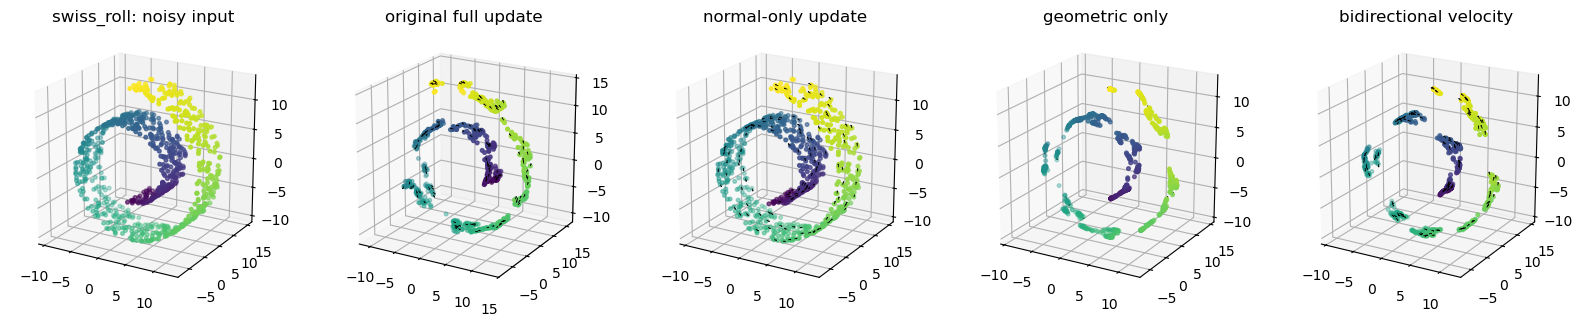

In [16]:
all_rows = []
for dataset in ["circle", "yshape", "xshape", "swiss_roll"]:
    for seed in range(5):
        df, _, _, _, _ = run_one_experiment(dataset, seed=seed)
        df["dataset"] = dataset
        df["seed"] = seed
        all_rows.append(df)

res = pd.concat(all_rows, ignore_index=True)
summary = res.groupby(["dataset", "method"]).agg(["mean", "std"])
Path("velocity_mf_outputs").mkdir(exist_ok=True)
res.to_csv("velocity_mf_outputs/all_metrics.csv", index=False)
summary.to_csv("velocity_mf_outputs/summary_metrics.csv")

display(res.head())
display(summary)


## Saved figures

If you run the batch cell above, the figures below should appear in `velocity_mf_outputs/`.


circle_comparison.png


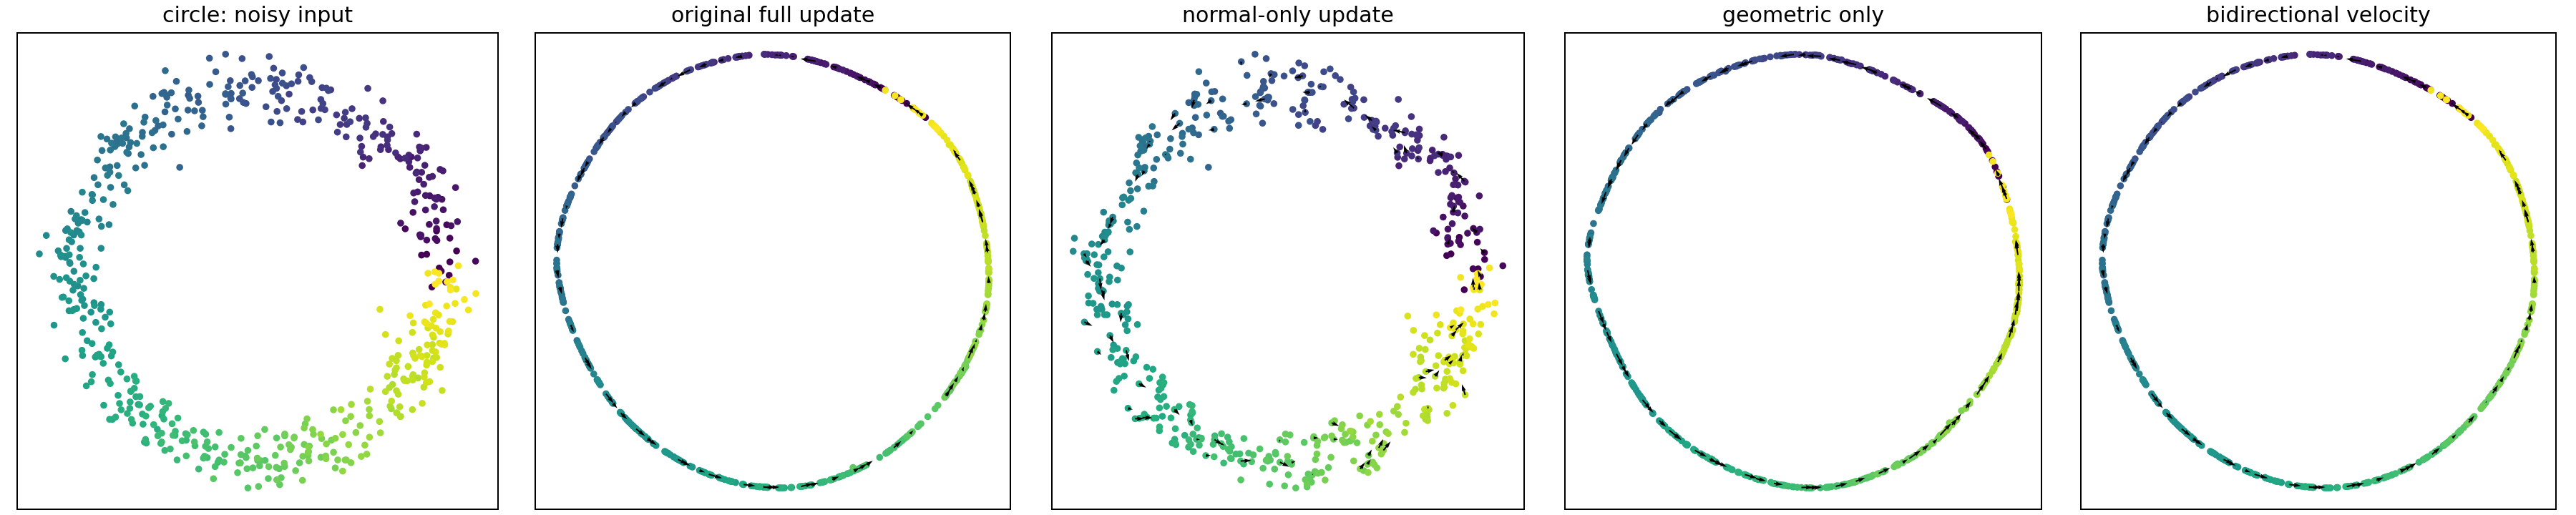

swiss_roll_comparison.png


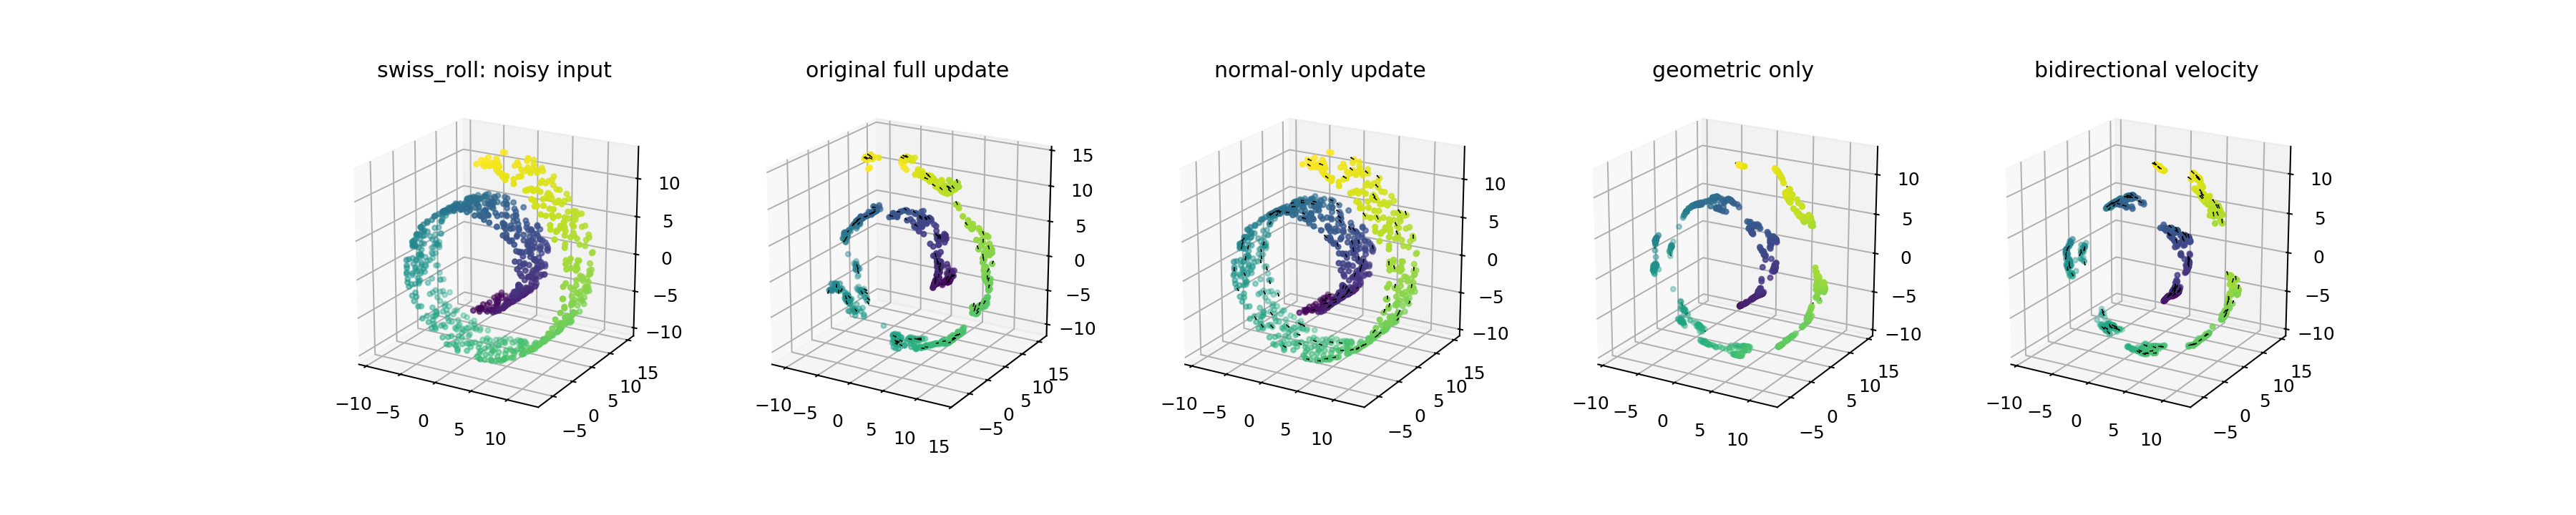

xshape_comparison.png


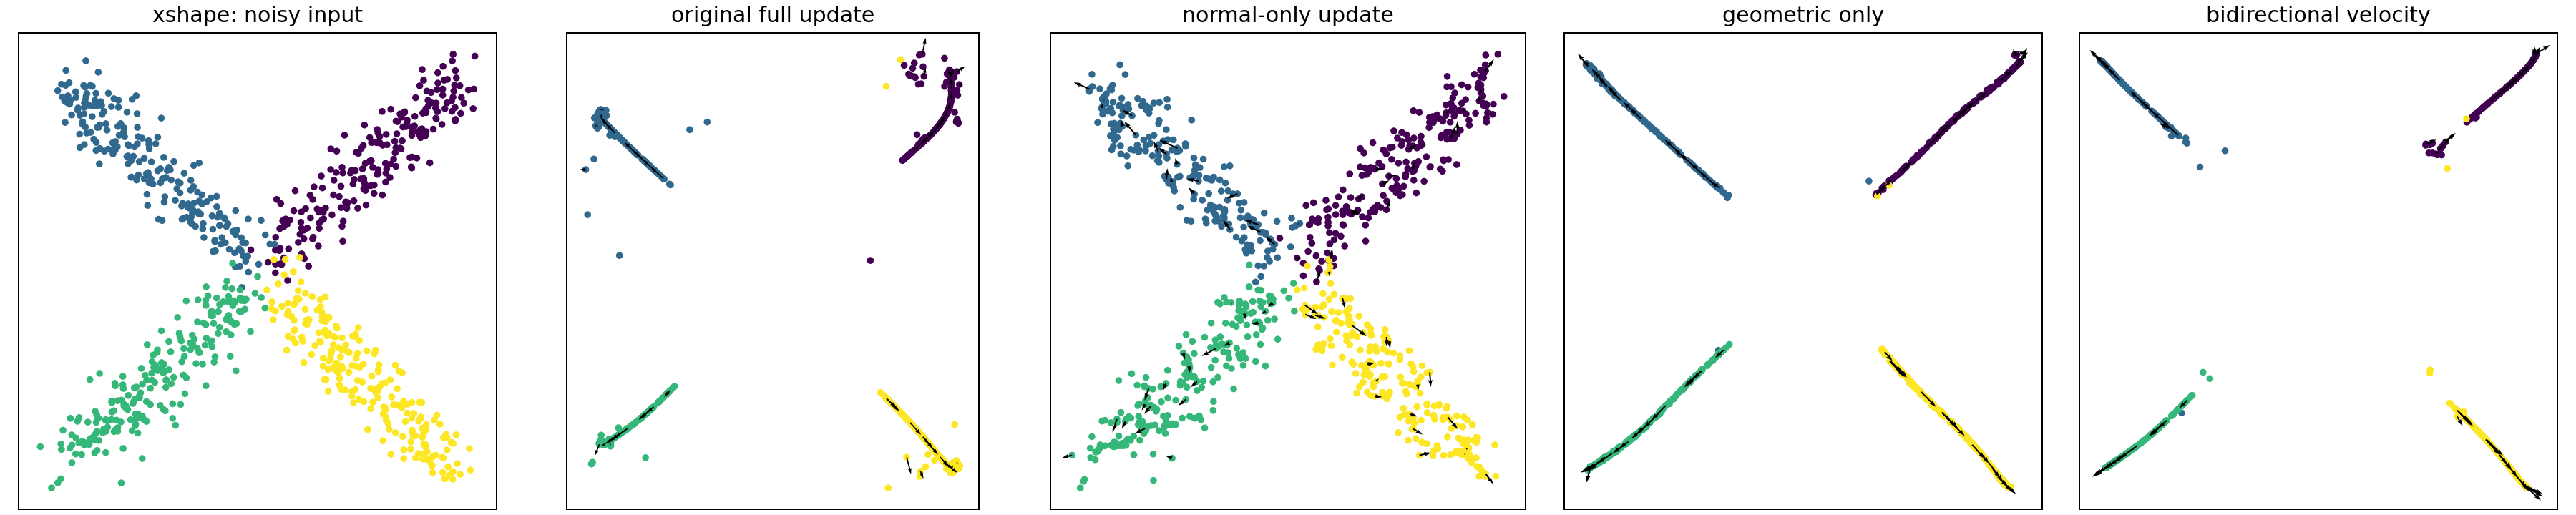

yshape_comparison.png


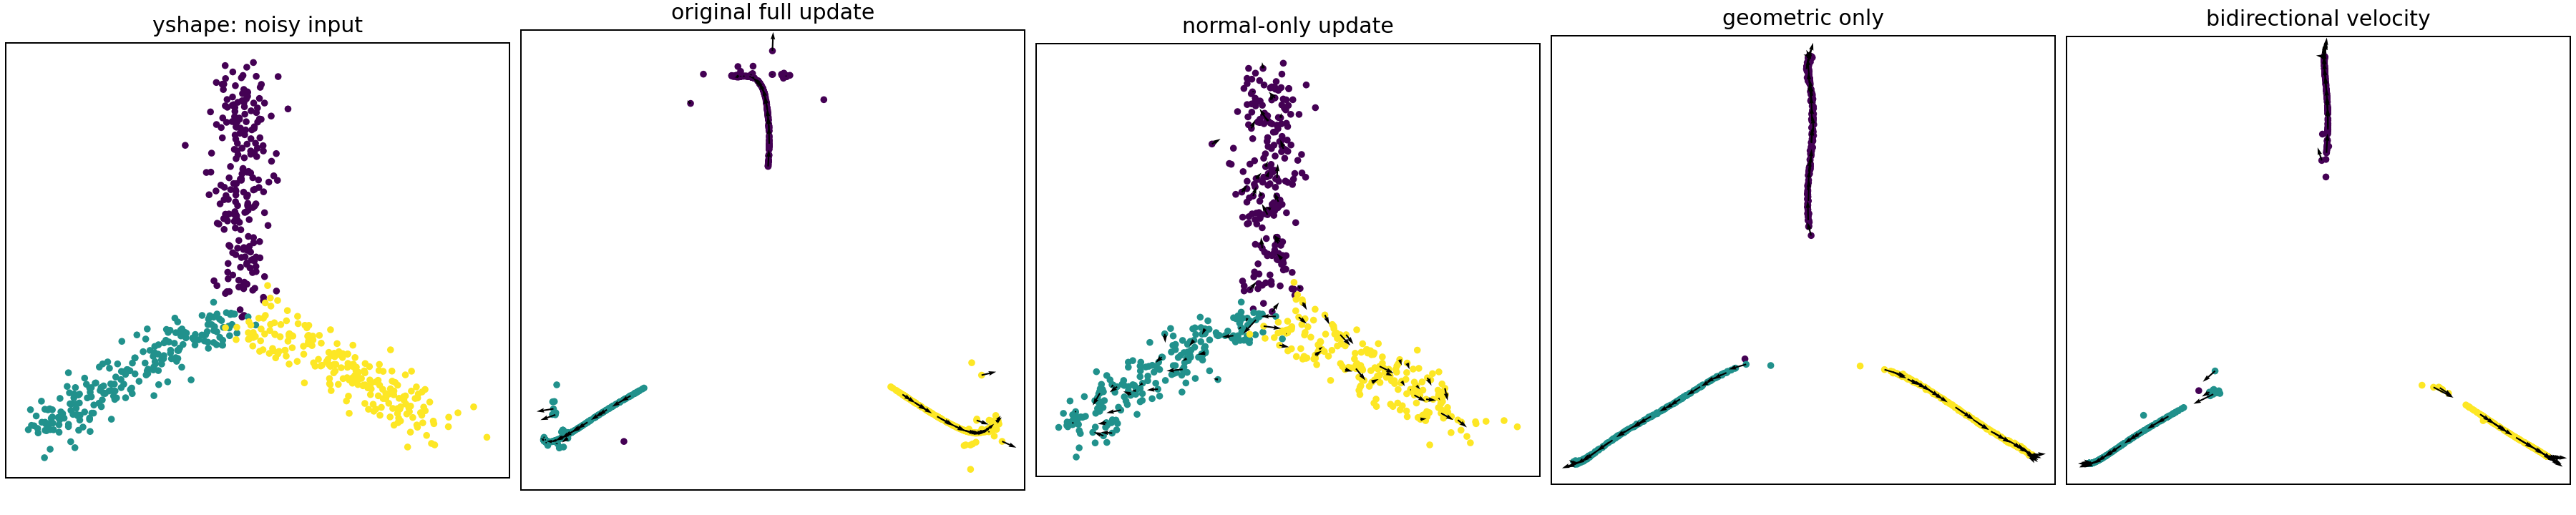

In [17]:
from IPython.display import Image, display

for path in sorted(Path("velocity_mf_outputs").glob("*.png")):
    print(path.name)
    display(Image(filename=str(path), width=650))
